# Notebook to create legend for figures

In [1]:
# imports
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from pathlib import Path


In [2]:
# styles and structure

MODEL_STYLES = {
    "Unet Image+CLIP":                  dict(label="UNet",              color="deepskyblue"),
    "SwinUNETR Image+CLIP":             dict(label="Swin",              color="steelblue"),
    "SwinUNETR Image+CLIP (overtrain)": dict(label="Swin (over)",       color="navy"),
    "Unet Image-only":                  dict(label="UNet",              color="orange"),
    "Unet Random-init":                 dict(label="UNet",              color="red"),
    "SwinUNETR Random-init":            dict(label="Swin",              color="maroon"),
    "microSAM large":                   dict(label="uSAM (l)",          color="forestgreen"),
    "microSAM base":                    dict(label="uSAM (b)",          color="darkseagreen"),
    "CellSeg3D":                        dict(label="CellSeg3D",         color="hotpink"),
    "Cellpose 2D":                      dict(label="Cellpose (2D)",     color="purple"),
    "ResNet":                           dict(label="ResNet",            color="chocolate"),
    "PCA+LR":                           dict(label="PCA",               color="gray"),
}

SPACER = ("SPACER", "")

LEGEND_STRUCTURE = [
    ("HEADER", "Img+T"),
    "Unet Image+CLIP",
    "SwinUNETR Image+CLIP",
    "SwinUNETR Image+CLIP (overtrain)",

    SPACER, ("HEADER", "Img"),
    "Unet Image-only",

    SPACER, ("HEADER", "Scr"),
    "Unet Random-init",
    "SwinUNETR Random-init",

    SPACER, ("HEADER", "Seg bases"),
    "microSAM large",
    "microSAM base",
    "CellSeg3D",
    "Cellpose 2D",

    SPACER, ("HEADER", "Clas bases"),
    "ResNet",
    "PCA+LR",
]


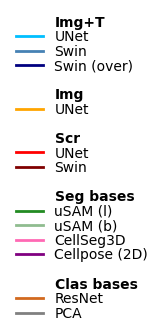

In [3]:
# create legend

handles = []
labels = []

for item in LEGEND_STRUCTURE:
    if isinstance(item, tuple) and item[0] == "SPACER":
        handles.append(Line2D([], [], linestyle="none", linewidth=0))
        labels.append("")  # small blank line
    elif isinstance(item, tuple) and item[0] == "HEADER":
        handles.append(Line2D([], [], linestyle="none", linewidth=0))
        labels.append(item[1])
    else:
        style = MODEL_STYLES[item]
        handles.append(Line2D([], [], color=style["color"], linewidth=2))
        labels.append(style["label"])

fig = plt.figure(figsize=(1, 2.2))

legend = fig.legend(
    handles=handles,
    labels=labels,
    loc="center",
    frameon=False,
    handlelength=2,
    handletextpad=0.8,
    labelspacing=0.04,
)

# Center + bold headers
for text, item in zip(legend.get_texts(), LEGEND_STRUCTURE):
    if isinstance(item, tuple) and item[0] == "HEADER":
        text.set_fontweight("bold")
        text.set_ha("center")
        text.set_x(0.5)

plt.axis("off")
plt.show()


In [4]:
# save legend as separate file

# Output directory
OUTDIR = Path("/midtier/paetzollab/scratch/ads4015/lsm_fm_paper/figs")
OUTDIR.mkdir(parents=True, exist_ok=True)

# Save files
fig.savefig(
    OUTDIR / "model_legend.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    OUTDIR / "model_legend.pdf",
    bbox_inches="tight",
    facecolor="white"
)
